Author: Krish

In [60]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

### User input required
Put the data path on your system in the cell below

In [61]:
data_path = "OneDrive_3_10-3-2025"

### User input ends

### Reading all filenames in the data folder

In [62]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


### Reading all data files
The code chunk below reads and appends all the CAR data files. The first two rows of each file are blank and thus ignored.

In [63]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

### Time datatype conversion
The code chunk below converts time from string to datetime datatype.

In [64]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))

In [65]:
# Checking the datatype of all columns
df_main.dtypes

Contact Session ID                  object
EP Name                             object
Flow Name                           object
Activity Name                       object
Activity Start Timestamp    datetime64[ns]
Queue Name                          object
Agent Name                          object
Termination Reason                  object
dtype: object

In [66]:
# Ensure the timestamp column is datetime
df_main["Activity Start Timestamp"] = pd.to_datetime(df_main["Activity Start Timestamp"], errors="coerce")

# Now extract hour safely
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour


### Prepocessing

In [67]:
# Ensure datetime and handy fields
df_main["Activity Start Timestamp"] = pd.to_datetime(df_main["Activity Start Timestamp"], errors="coerce")
df_main["_dt"] = df_main["Activity Start Timestamp"]
df_main["hour"] = df_main["_dt"].dt.hour
df_main["date"] = df_main["_dt"].dt.date

FAMILY_EP = "Legal Family Menu Telephony EP"


### Termination Reason by Chatbot Usage Analysis

Chatbot Used,No Chatbot,Chatbot
Simplified Reason,,
Agent Left,23,83
Customer Left,1037,328
Other,21,1


Chatbot Used,No Chatbot %,Chatbot %
Simplified Reason,,
Agent Left,2.13,20.15
Customer Left,95.93,79.61
Other,1.94,0.24


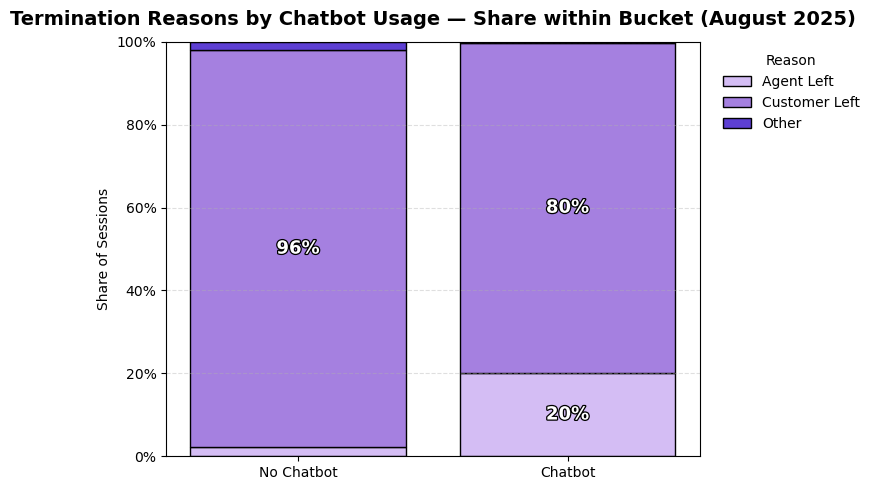

In [76]:
# Filter August 2025
aug = df_main[(df_main["_dt"].dt.year == 2025) & (df_main["_dt"].dt.month == 8)].copy()

# Sessions that touched Family EP (and chatbot flag)
family_aug = aug[aug["EP Name"] == FAMILY_EP].copy()
family_aug["Chatbot Used"] = family_aug["Activity Name"] == "TransferToSafeHaven"
family_ids = family_aug["Contact Session ID"].dropna().unique()

# Collect unique, non-empty termination reasons for those sessions (within August)
def clean_unique_reasons(x):
    cleaned = [str(r).strip() for r in x if str(r).strip() not in ["", "N/A", "nan", "None"]]
    unique_vals = list(dict.fromkeys(cleaned))  # preserve order
    return ", ".join(unique_vals) if unique_vals else "Unspecified"

term_by_id = (
    aug[aug["Contact Session ID"].isin(family_ids)]
    .groupby("Contact Session ID")["Termination Reason"]
    .apply(clean_unique_reasons)
    .reset_index(name="Termination Reasons")
)

chatbot_by_id = family_aug.groupby("Contact Session ID", as_index=False)["Chatbot Used"].max()

summary = (
    chatbot_by_id
    .merge(term_by_id, on="Contact Session ID", how="left")
    .fillna({"Termination Reasons":"Unspecified"})
)

# Simplify reasons to 3 buckets
def simplify(reason):
    if "Customer Left" in reason:
        return "Customer Left"
    if "Agent Left" in reason:
        return "Agent Left"
    return "Other"

summary["Simplified Reason"] = summary["Termination Reasons"].apply(simplify)

# Counts → table
counts = (
    summary.groupby(["Simplified Reason", "Chatbot Used"])
           .size()
           .reset_index(name="Count")
)

termination_table = (
    counts.pivot(index="Simplified Reason", columns="Chatbot Used", values="Count")
          .fillna(0)
          .rename(columns={False: "No Chatbot", True: "Chatbot"})
          .astype(int)
)

# Convert to within-bucket percentages (columns sum to 100%)
cols = [c for c in ["No Chatbot", "Chatbot"] if c in termination_table.columns]
col_sums = termination_table[cols].sum(axis=0)
pct = (termination_table[cols].div(col_sums.where(col_sums != 0, 1), axis=1) * 100).round(2)

display(termination_table)
display(pct.add_suffix(" %"))

# --- Stacked percent bar chart (purple, black borders, outlined labels) ---
colors = ["#d4bdf4", "#a580e0", "#5d3fd3"]  # light → dark
fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(cols))

for i, reason in enumerate(pct.index):
    vals = pct.loc[reason, cols].values
    ax.bar(cols, vals, bottom=bottom,
           label=reason, color=colors[i % len(colors)], edgecolor="black", linewidth=1)
    # Labels inside segments (>=3%)
    for j, v in enumerate(vals):
        if v >= 3:
            txt = ax.text(j, bottom[j] + v/2, f"{v:.0f}%",
                          ha="center", va="center", fontsize=13, color="white", weight="bold")
            txt.set_path_effects([
                path_effects.Stroke(linewidth=1.8, foreground="black"),
                path_effects.Normal()
            ])
    bottom += vals

ax.set_title("Termination Reasons by Chatbot Usage — Share within Bucket (August 2025)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Share of Sessions")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Reason", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("termination_reason_plot.png", dpi=300, bbox_inches="tight")
plt.show()



### Duration of calls analysis

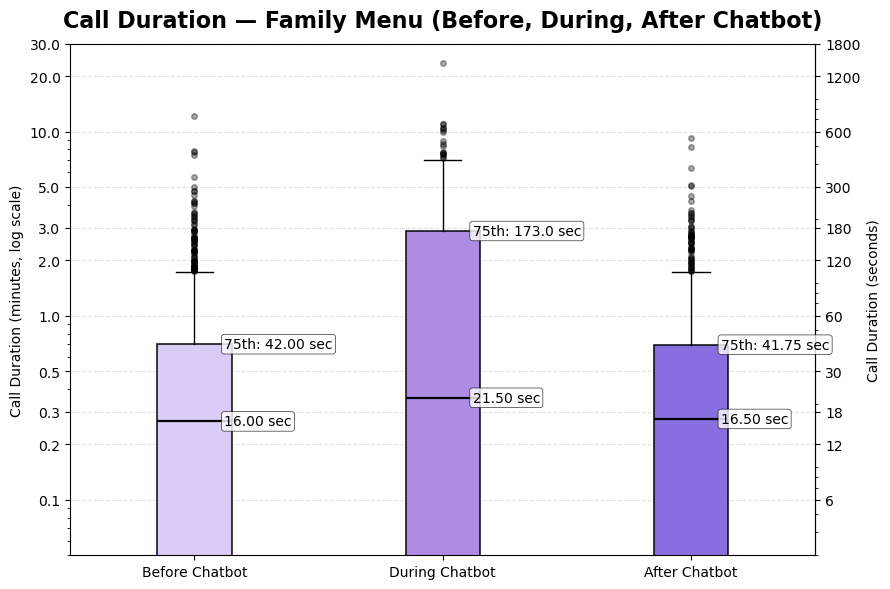

In [75]:
# --- Boxplot: Before / During / After chatbot (log scale), with annotations ---

# Windows (same as you set above)
chatbot_start = pd.Timestamp("2025-08-11")
chatbot_end   = pd.Timestamp("2025-08-29")
before_start  = chatbot_start - pd.Timedelta(days=19)
before_end    = chatbot_start - pd.Timedelta(days=1)
after_start   = chatbot_end + pd.Timedelta(days=1)
after_end     = chatbot_end + pd.Timedelta(days=19)

# Family EP rows
fam = df_main[df_main["EP Name"] == FAMILY_EP].copy()

# Duration per session (minutes)
duration_df = (
    fam.groupby("Contact Session ID", as_index=False)
       .agg(start_time=("_dt", "min"), end_time=("_dt", "max"))
)
duration_df["Duration_min"] = (duration_df["end_time"] - duration_df["start_time"]).dt.total_seconds() / 60

# Label period by start time
def label_period(ts):
    if before_start <= ts <= before_end:
        return "Before Chatbot"
    elif chatbot_start <= ts <= chatbot_end:
        return "During Chatbot"
    elif after_start <= ts <= after_end:
        return "After Chatbot"
    else:
        return None

duration_df["Period"] = duration_df["start_time"].apply(label_period)
duration_df = duration_df[duration_df["Period"].notna()].copy()

# Data in plotting order
order = ["Before Chatbot", "During Chatbot", "After Chatbot"]
series = [duration_df.loc[duration_df["Period"] == p, "Duration_min"].dropna() for p in order]

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

bp = ax.boxplot(
    series,
    patch_artist=True,
    labels=order,
    showfliers=True,  # make sure outliers are drawn
    medianprops=dict(color="black", linewidth=1.6),
    boxprops=dict(linewidth=1.2, edgecolor="black"),
    whiskerprops=dict(color="black", linewidth=1),
    capprops=dict(color="black", linewidth=1),
    flierprops=dict(marker="o", markerfacecolor="black", alpha=0.35, markersize=4),
)

# Purple fills
box_colors = ["#d8c6f7", "#a580e0", "#7b5edb"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set(facecolor=color, alpha=0.9)

# --- Y axis (log), show ALL outliers & ensure 10 and 30 min ticks ---
dur = duration_df["Duration_min"].dropna()
top_ylim = max(30, dur.max()*1.05)   # at least 30 min, otherwise slightly above max to include all fliers
ax.set_yscale("log")
ax.set_ylim(bottom=0.05, top=top_ylim)

# Tick set that includes 10 and 30
tick_candidates = [0.1, 0.2, 0.3, 0.5, 1, 2, 3, 5, 10, 20, 30, 60, 120]
ax.set_yticks([t for t in tick_candidates if t <= top_ylim])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_yaxis().set_minor_formatter(plt.NullFormatter())

# --- Right axis in seconds (correct 60× mapping) ---
secax = ax.secondary_yaxis('right', functions=(lambda m: m*60, lambda s: s/60))
secax.set_ylabel("Call Duration (seconds)")
secax.set_yscale("log")
secax.set_yticks([t*60 for t in tick_candidates if t <= top_ylim])
secax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

# --- Annotations: median & 75th percentile for each box ---
def fmt_minutes(x):
    return f"{x*60:.2f} sec" if x < 1 else f"{x*60:.1f} sec"

x_positions = np.arange(1, len(series)+1)
for x, s in zip(x_positions, series):
    if len(s) == 0:
        continue
    med = float(np.median(s))
    q3  = float(np.percentile(s, 75))
    # place labels slightly to the right of each box
    ax.text(x + 0.12, med, fmt_minutes(med),
            va="center", ha="left", fontsize=10, color="black",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=0.5, alpha=0.8))
    ax.text(x + 0.12, q3,  f"75th: {fmt_minutes(q3)}",
            va="center", ha="left", fontsize=10, color="black",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=0.5, alpha=0.8))

ax.set_title("Call Duration — Family Menu (Before, During, After Chatbot)",
             fontsize=16, fontweight="bold", pad=12)
ax.set_ylabel("Call Duration (minutes, log scale)")
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("call_duration_plot.png", dpi=300, bbox_inches="tight")
plt.show()



### Time spending in Family Menu

=== Menu navigation depth (hops before queue/transfer) ===


,Avg Menu Hops,Median Menu Hops
Period,,
After Chatbot,1.11,1.0
Before Chatbot,1.06,1.0
During Chatbot,0.32,0.0


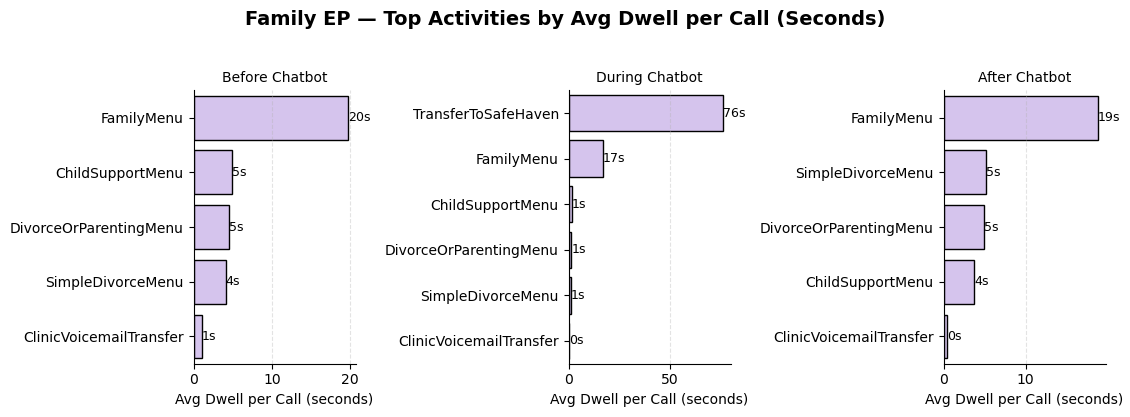

In [74]:
# Defining window
FAMILY_EP = "Legal Family Menu Telephony EP"
chatbot_start = pd.Timestamp("2025-08-11")
chatbot_end   = pd.Timestamp("2025-08-29")
before_start  = chatbot_start - pd.Timedelta(days=19)
before_end    = chatbot_start - pd.Timedelta(days=1)
after_start   = chatbot_end + pd.Timedelta(days=1)
after_end     = chatbot_end + pd.Timedelta(days=19)

# Keep all Family EP rows
fam = df_main[df_main["EP Name"] == FAMILY_EP].copy()
fam["_dt"] = pd.to_datetime(fam["Activity Start Timestamp"], errors="coerce")
fam = fam.dropna(subset=["_dt"])

# Apply period labels
def label_period(ts):
    if before_start <= ts <= before_end:
        return "Before Chatbot"
    elif chatbot_start <= ts <= chatbot_end:
        return "During Chatbot"
    elif after_start <= ts <= after_end:
        return "After Chatbot"
    return None

fam["Period"] = fam["_dt"].apply(label_period)
fam = fam[fam["Period"].notna()].copy()

# Sort by session/time and compute dwell
fam = fam.sort_values(["Contact Session ID", "_dt"])
fam["next_dt"] = fam.groupby("Contact Session ID")["_dt"].shift(-1)
fam["dwell_sec"] = (fam["next_dt"] - fam["_dt"]).dt.total_seconds().clip(lower=0)

# Use filled names to fix NaN continuity
fam["Activity Name (filled)"] = (
    fam.groupby("Contact Session ID")["Activity Name"]
       .transform(lambda s: s.ffill())
       .fillna("Unknown")
)

# Identify Kind
def tag_kind(name: str):
    s = str(name)
    if "Queue" in s:
        return "Queue"
    if "Transfer" in s:
        return "Transfer"
    if "Menu" in s:
        return "Menu"
    return "Other"

fam["Kind"] = fam["Activity Name (filled)"].apply(tag_kind)

# --- Session-level summary
def compressed_path(series):
    out, prev = [], None
    for x in series:
        x = str(x)
        if x == "Unknown":
            continue
        if x != prev:
            out.append(x)
            prev = x
    return " > ".join(out) if out else "Unknown"

def menu_hops_before_exit(df_session):
    kinds = df_session["Kind"].tolist()
    hops = 0
    for i in range(len(kinds) - 1):
        if kinds[i] == "Menu" and kinds[i+1] == "Menu":
            hops += 1
        if kinds[i+1] in ("Queue", "Transfer"):
            break
    return hops

def reached(df_session, needle):
    return df_session["Activity Name (filled)"].eq(needle).any()

session_summary = (
    fam.groupby("Contact Session ID")
       .apply(lambda g: pd.Series({
           "Period": g["Period"].iloc[0],
           "Path": compressed_path(g["Activity Name (filled)"]),
           "MenuHopsBeforeExit": menu_hops_before_exit(g),
           "ReachedFamilyQueue": reached(g, "FamilyQueue"),
           "UsedSafeHaven": g["Activity Name (filled)"].eq("TransferToSafeHaven").any(),
           "TotalDwellSec": g["dwell_sec"].sum()
       }))
       .reset_index()
)

# Dwell time by activity
dwell_by_activity = (
    fam.groupby(["Period", "Activity Name (filled)"], as_index=False)["dwell_sec"].sum()
    .rename(columns={"Activity Name (filled)": "Activity Name"})
)

# Menu navigation depth
depth_stats = (
    session_summary.groupby("Period")["MenuHopsBeforeExit"]
    .agg(["mean", "median"])
    .round(2)
    .rename(columns={"mean": "Avg Menu Hops", "median": "Median Menu Hops"})
)

print("=== Menu navigation depth (hops before queue/transfer) ===")
display(depth_stats)

# Top activities by average dwell per call (SECONDS)
period_order = ["Before Chatbot", "During Chatbot", "After Chatbot"]

# Count sessions per period
sessions_per_period = (
    session_summary.groupby("Period")["Contact Session ID"]
    .nunique()
    .rename("n_calls_period")
    .reset_index()
)

# Total dwell by period/activity
avg_pa = dwell_by_activity.merge(sessions_per_period, on="Period", how="left")
avg_pa["avg_sec_per_call"] = avg_pa["dwell_sec"] / avg_pa["n_calls_period"]
avg_pa["Period"] = pd.Categorical(avg_pa["Period"], categories=period_order, ordered=True)

# Top per period
TOP_K = 8
top_avg = (
    avg_pa.sort_values(["Period", "avg_sec_per_call"], ascending=[True, False])
          .groupby("Period")
          .head(TOP_K)
          .copy()
)

#Plot
g = sns.catplot(
    data=top_avg,
    x="avg_sec_per_call", y="Activity Name",
    col="Period", col_order=period_order,
    kind="bar",
    sharex=False, sharey=False,
    height=4, aspect=0.95,
    palette=["#d4bdf4"], edgecolor="black"
)

g.set_titles("{col_name}")
g.set_axis_labels("Avg Dwell per Call (seconds)", "")

# Value labels
for ax, (period, sub) in zip(g.axes.flat, top_avg.groupby("Period")):
    for patch, (_, row) in zip(ax.patches, sub.iterrows()):
        w = patch.get_width()
        y = patch.get_y() + patch.get_height()/2
        ax.text(w, y, f"{w:.0f}s", va="center", ha="left", fontsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.35)

plt.suptitle("Family EP — Top Activities by Avg Dwell per Call (Seconds)",
             y=1.03, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("family_menu_dwell_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [73]:
plt.savefig("family_menu_dwell_plot.png", dpi=300, bbox_inches="tight")
plt.show()


<Figure size 640x480 with 0 Axes>